In [14]:
# Menginstal MLJAR Supervised dan library pendukung lainnya
!pip install mljar-supervised ucimlrepo scikit-learn pandas matplotlib

In [15]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Mengambil dataset Heart Disease
print("Sedang menarik data dari UCI...")
heart_disease = fetch_ucirepo(id=45)

# Memisahkan Fitur (X) dan Target (y)
X = heart_disease.data.features
y = heart_disease.data.targets.iloc[:, 0]

# Menampilkan informasi variabel untuk bahan laporan
print("\n=== INFORMASI VARIABEL (FITUR) ===")
print(heart_disease.variables[['name', 'role', 'type', 'description']])

# Penyesuaian Target Klasifikasi Biner
y = (y > 0).astype(int)

print("\n=== RINGKASAN DATA AWAL ===")
print(f"Jumlah baris: {X.shape[0]}")
print(f"Jumlah fitur: {X.shape[1]}")
print("Distribusi target:")
print(y.value_counts().sort_index())

Sedang menarik data dari UCI...

=== INFORMASI VARIABEL (FITUR) ===
        name     role         type  \
0        age  Feature      Integer   
1        sex  Feature  Categorical   
2         cp  Feature  Categorical   
3   trestbps  Feature      Integer   
4       chol  Feature      Integer   
5        fbs  Feature  Categorical   
6    restecg  Feature  Categorical   
7    thalach  Feature      Integer   
8      exang  Feature  Categorical   
9    oldpeak  Feature      Integer   
10     slope  Feature  Categorical   
11        ca  Feature      Integer   
12      thal  Feature  Categorical   
13       num   Target      Integer   

                                          description  
0                                                None  
1                                                None  
2                                                None  
3   resting blood pressure (on admission to the ho...  
4                                   serum cholestoral  
5                     fas

## Exploratory Data Analysis
> Menampilkan ringkasan data, distribusi target, missing values, statistik deskriptif, dan korelasi fitur numerik sebelum masuk ke preprocessing.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Ringkasan struktur data
print("Bentuk fitur:", X.shape)
print("\nContoh 5 baris pertama:")
display(X.head())

Bentuk fitur: (303, 13)

Contoh 5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [19]:
# Missing values
missing_values = X.isna().sum().sort_values(ascending=False)
print("\n=== MISSING VALUES PER FITUR ===")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing values pada fitur.")


=== MISSING VALUES PER FITUR ===
ca      4
thal    2
dtype: int64


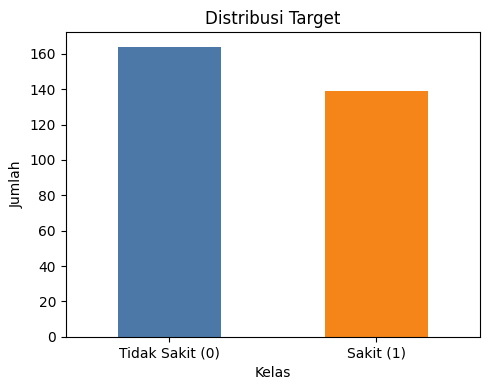

In [20]:
# Distribusi target
plt.figure(figsize=(5, 4))
target_counts = y.value_counts().sort_index()
target_counts.index = ["Tidak Sakit (0)", "Sakit (1)"]
target_counts.plot(kind="bar", color=["#4C78A8", "#F58518"])
plt.title("Distribusi Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF FITUR NUMERIK ===")
display(X.describe().T)


=== STATISTIK DESKRIPTIF FITUR NUMERIK ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


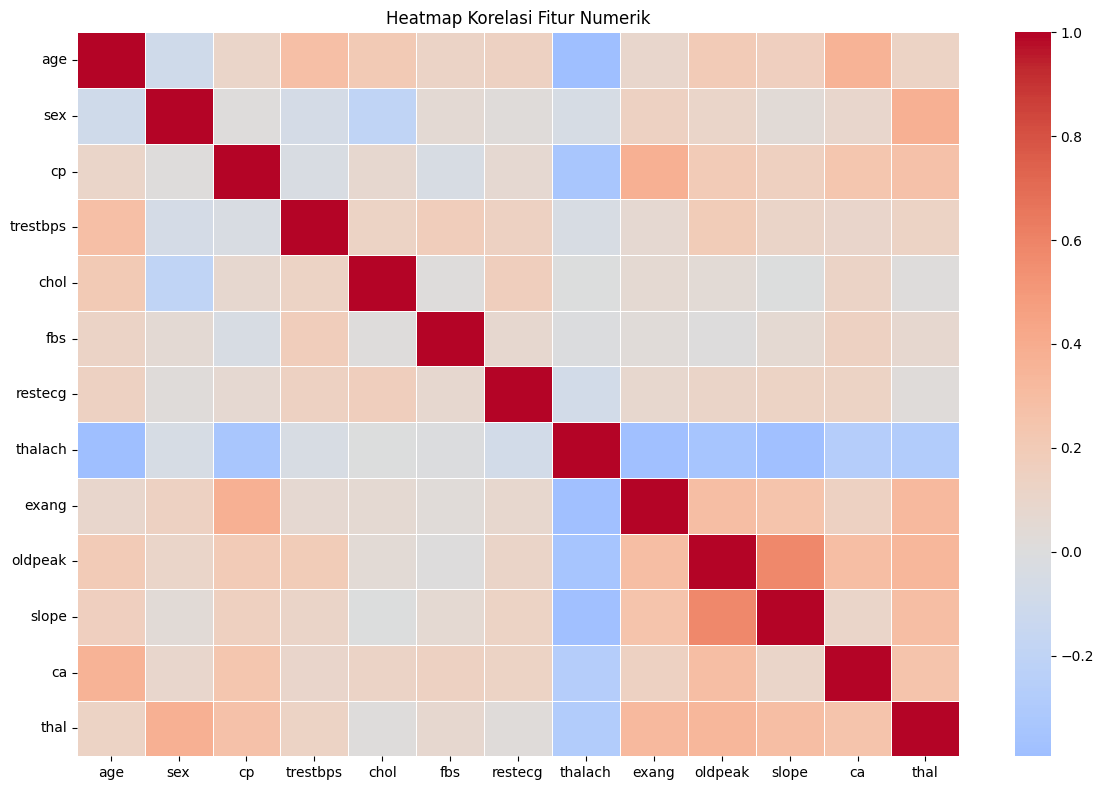

In [22]:
# Korelasi fitur numerik
plt.figure(figsize=(12, 8))
corr = X.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

## Pre-processing Data

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [24]:
# Teknik 1: Imputasi Median untuk menangani missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [25]:
# Teknik 2: Standardisasi fitur
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

In [26]:
# Split Data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
 )

print(f"Data latih: {len(X_train)} baris")
print(f"Data uji: {len(X_test)} baris")
print("Preprocessing selesai: imputasi, scaling, dan split data sudah dilakukan.")

Data latih: 242 baris
Data uji: 61 baris
Preprocessing selesai: imputasi, scaling, dan split data sudah dilakukan.


## Inisiasi AutoML MLJAR

In [29]:
from supervised.automl import AutoML
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [28]:
# Inisiasi MLJAR AutoML dengan mode "Explain" (Cocok untuk membuat laporan)
# eval_metric diatur ke 'logloss' atau 'auc' (standar klasifikasi), mesin akan otomatis menghitung Recall di laporannya nanti.
automl = AutoML(
    mode="Explain", 
    eval_metric="auc",
    total_time_limit=300 # Membatasi waktu pencarian maksimal 5 menit agar cepat
)

print("Memulai proses training MLJAR AutoML. Silakan tunggu sekitar 3-5 menit...\n")

# Memulai eksperimen
automl.fit(X_train, y_train.values.ravel())

print("\nProses training selesai! Model terbaik telah disimpan.")

Memulai proses training MLJAR AutoML. Silakan tunggu sekitar 3-5 menit...

AutoML directory: AutoML_2
The task is binary_classification with evaluation metric auc
AutoML will use algorithms: ['Baseline', 'Linear', 'Decision Tree', 'Random Forest', 'Xgboost', 'Neural Network']
AutoML will ensemble available models
AutoML steps: ['simple_algorithms', 'default_algorithms', 'ensemble']
* Step simple_algorithms will try to check up to 3 models
1_Baseline auc 0.5 trained in 0.68 seconds
2_DecisionTree auc 0.860931 trained in 7.05 seconds
3_Linear auc 0.931818 trained in 3.66 seconds
* Step default_algorithms will try to check up to 3 models
4_Default_Xgboost auc 0.878788 trained in 3.29 seconds
5_Default_NeuralNetwork auc 0.919913 trained in 1.83 seconds
6_Default_RandomForest auc 0.906926 trained in 3.05 seconds
* Step ensemble will try to check up to 1 model
Ensemble auc 0.931818 trained in 1.47 seconds
AutoML fit time: 29.82 seconds
AutoML best model: 3_Linear

Proses training selesai! Mo

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.90      0.85      0.88        33
      Sakit (1)       0.83      0.89      0.86        28

       accuracy                           0.87        61
      macro avg       0.87      0.87      0.87        61
   weighted avg       0.87      0.87      0.87        61


=== CONFUSION MATRIX ===


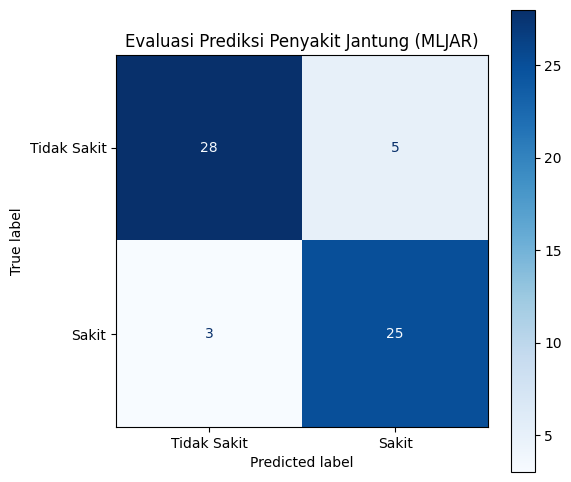

In [30]:
# Meminta MLJAR memprediksi data testing menggunakan model terbaiknya
y_pred = automl.predict(X_test)

# Menampilkan Laporan Metrik (Fokus pada angka Recall)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Sakit (0)', 'Sakit (1)']))

# Membuat Grafik Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Sakit', 'Sakit'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Evaluasi Prediksi Penyakit Jantung (MLJAR)")
plt.show()

=== RINGKASAN METRIK PER MODEL (VALIDATION) ===


,model,accuracy,precision,recall,f1,balanced_acc,mcc,kappa,auc,average_precision,logloss,n_data
0,5_Default_NeuralNetwork,0.869,0.885,0.821,0.852,0.865,0.736,0.734,0.920,0.924,0.351,61
1,3_Linear,0.852,0.828,0.857,0.842,0.853,0.704,0.704,0.932,0.939,0.335,61
2,6_Default_RandomForest,0.836,0.846,0.786,0.815,0.832,0.670,0.668,0.907,0.909,0.408,61
3,2_DecisionTree,0.820,0.793,0.821,0.807,0.820,0.638,0.638,0.861,0.827,0.993,61
4,4_Default_Xgboost,0.803,0.900,0.643,0.750,0.791,0.618,0.595,0.879,0.884,0.588,61
5,1_Baseline,0.541,0.000,0.000,0.000,0.500,0.000,0.000,0.500,0.459,0.690,61



=== CLASSIFICATION REPORT TIAP MODEL ===

--- 5_Default_NeuralNetwork ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.86      0.91      0.88        33
      Sakit (1)       0.88      0.82      0.85        28

       accuracy                           0.87        61
      macro avg       0.87      0.87      0.87        61
   weighted avg       0.87      0.87      0.87        61



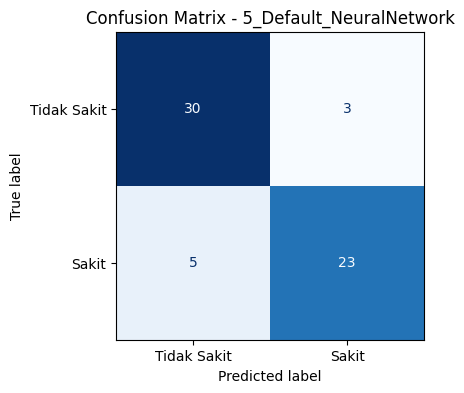


--- 3_Linear ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.88      0.85      0.86        33
      Sakit (1)       0.83      0.86      0.84        28

       accuracy                           0.85        61
      macro avg       0.85      0.85      0.85        61
   weighted avg       0.85      0.85      0.85        61



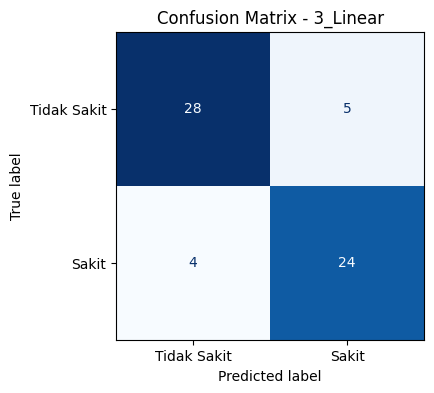


--- 6_Default_RandomForest ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.83      0.88      0.85        33
      Sakit (1)       0.85      0.79      0.81        28

       accuracy                           0.84        61
      macro avg       0.84      0.83      0.83        61
   weighted avg       0.84      0.84      0.84        61



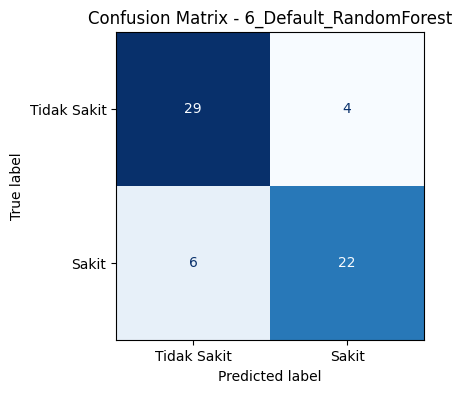


--- 2_DecisionTree ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.84      0.82      0.83        33
      Sakit (1)       0.79      0.82      0.81        28

       accuracy                           0.82        61
      macro avg       0.82      0.82      0.82        61
   weighted avg       0.82      0.82      0.82        61



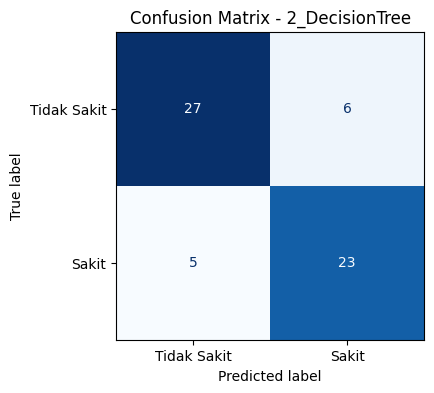


--- 4_Default_Xgboost ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.76      0.94      0.84        33
      Sakit (1)       0.90      0.64      0.75        28

       accuracy                           0.80        61
      macro avg       0.83      0.79      0.79        61
   weighted avg       0.82      0.80      0.80        61



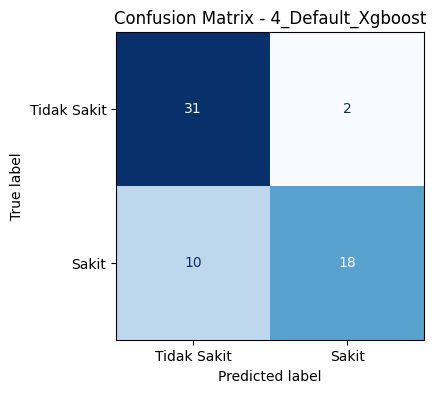


--- 1_Baseline ---
                 precision    recall  f1-score   support

Tidak Sakit (0)       0.54      1.00      0.70        33
      Sakit (1)       0.00      0.00      0.00        28

       accuracy                           0.54        61
      macro avg       0.27      0.50      0.35        61
   weighted avg       0.29      0.54      0.38        61



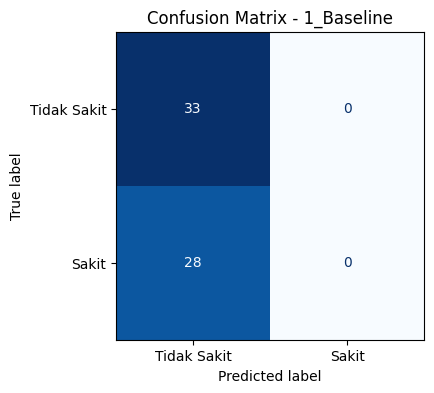

In [10]:
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    log_loss,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    average_precision_score
    )
import pandas as pd
import matplotlib.pyplot as plt

# Evaluasi setiap model AutoML berdasarkan file prediksi validasi
results_dir = Path("AutoML_1")
prediction_files = sorted(results_dir.glob("*/predictions_validation.csv"))

if not prediction_files:
    print("File predictions_validation.csv tidak ditemukan di folder AutoML_1.")
else:
    rows = []

    for pred_file in prediction_files:
        model_name = pred_file.parent.name
        df_pred = pd.read_csv(pred_file)

        y_true = df_pred["target"].astype(int)
        y_prob = df_pred["prediction"].astype(float)
        y_hat = (y_prob >= 0.5).astype(int)

        rows.append({
            "model": model_name,
            "accuracy": accuracy_score(y_true, y_hat),
            "precision": precision_score(y_true, y_hat, zero_division=0),
            "recall": recall_score(y_true, y_hat, zero_division=0),
            "f1": f1_score(y_true, y_hat, zero_division=0),
            "balanced_acc": balanced_accuracy_score(y_true, y_hat),
            "mcc": matthews_corrcoef(y_true, y_hat),
            "kappa": cohen_kappa_score(y_true, y_hat),
            "auc": roc_auc_score(y_true, y_prob),
            "average_precision": average_precision_score(y_true, y_prob),
            "logloss": log_loss(y_true, y_prob, labels=[0, 1]),
            "n_data": len(y_true),
        })

    metrics_df = pd.DataFrame(rows).sort_values(by="f1", ascending=False).reset_index(drop=True)

    print("=== RINGKASAN METRIK PER MODEL (VALIDATION) ===")
    display(metrics_df.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "balanced_acc": "{:.3f}",
        "mcc": "{:.3f}",
        "kappa": "{:.3f}",
        "auc": "{:.3f}",
        "average_precision": "{:.3f}",
        "logloss": "{:.3f}",
    }))

    print("\n=== CLASSIFICATION REPORT TIAP MODEL ===")
    for _, r in metrics_df.iterrows():
        model_name = r["model"]
        pred_file = results_dir / model_name / "predictions_validation.csv"
        df_pred = pd.read_csv(pred_file)

        y_true = df_pred["target"].astype(int)
        y_prob = df_pred["prediction"].astype(float)
        y_hat = (y_prob >= 0.5).astype(int)

        print(f"\n--- {model_name} ---")
        print(classification_report(
            y_true,
            y_hat,
            target_names=["Tidak Sakit (0)", "Sakit (1)"],
            zero_division=0
        ))

        cm = confusion_matrix(y_true, y_hat)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Tidak Sakit", "Sakit"]
        )
        fig, ax = plt.subplots(figsize=(4, 4))
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

## Evolutionary Decision Tree

In [31]:
# Instal library DEAP untuk algoritma evolusi
!pip install deap

In [32]:
from deap import base, creator, tools, algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, make_scorer
import numpy as np
import random

In [33]:
# Definisikan Ruang Pencarian (Search Space) untuk Hyperparameter
MAX_DEPTH_MIN, MAX_DEPTH_MAX = 1, 20
MIN_SAMPLES_SPLIT_MIN, MIN_SAMPLES_SPLIT_MAX = 2, 20
MIN_SAMPLES_LEAF_MIN, MIN_SAMPLES_LEAF_MAX = 1, 10
CRITERION_OPTIONS = ['gini', 'entropy']

# Definisikan Jenis Individu 
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Inisialisasi Toolbox DEAP
toolbox = base.Toolbox()

# Fungsi untuk menghasilkan setiap hyperparameter secara acak
toolbox.register("attr_max_depth", random.randint, MAX_DEPTH_MIN, MAX_DEPTH_MAX)
toolbox.register("attr_min_samples_split", random.randint, MIN_SAMPLES_SPLIT_MIN, MIN_SAMPLES_SPLIT_MAX)
toolbox.register("attr_min_samples_leaf", random.randint, MIN_SAMPLES_LEAF_MIN, MIN_SAMPLES_LEAF_MAX)
toolbox.register("attr_criterion", random.choice, CRITERION_OPTIONS)

# Fungsi untuk merakit individu dari hyperparameter yang dihasilkan
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_max_depth, toolbox.attr_min_samples_split,
                  toolbox.attr_min_samples_leaf, toolbox.attr_criterion), n=1)

# Fungsi untuk membuat populasi
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Definisikan Fungsi Fitness (Evaluasi)
def evaluate_dt(individual):
    max_depth = individual[0]
    min_samples_split = individual[1]
    min_samples_leaf = individual[2]
    criterion = individual[3]
    if min_samples_split < min_samples_leaf:
        min_samples_split = min_samples_leaf + 1 # Pastikan min_samples_split setidaknya 1 lebih besar dari min_samples_leaf


    # Buat model Decision Tree dengan hyperparameter dari individu
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42 # Untuk reproduksibilitas
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    return f1,

toolbox.register("evaluate", evaluate_dt)

Memulai Algoritma Genetika untuk 20 generasi dengan populasi 50...
gen	nevals	avg     	std      	min     	max     
0  	0     	0,787264	0,0569917	0,607143	0,857143
1  	35    	0,825802	0,0267126	0,754098	0,857143
2  	37    	0,841737	0,0268085	0,745763	0,857143
3  	45    	0,848259	0,0244045	0,741935	0,857143
4  	37    	0,857143	1,11022e-16	0,857143	0,857143
5  	40    	0,854324	0,0160511  	0,745763	0,857143
6  	40    	0,852644	0,0231246  	0,709677	0,857143
7  	35    	0,850168	0,0285116  	0,709677	0,857143
8  	33    	0,852028	0,0208984  	0,741935	0,857143
9  	39    	0,855738	0,00983607 	0,786885	0,857143
10 	38    	0,85219 	0,0242616  	0,733333	0,857143
11 	45    	0,850954	0,0270773  	0,698413	0,857143
12 	31    	0,849714	0,0304387  	0,695652	0,857143
13 	34    	0,852371	0,0211307  	0,733333	0,857143
14 	45    	0,854188	0,0144935  	0,779661	0,857143
15 	39    	0,853835	0,0193787  	0,721311	0,857143
16 	34    	0,849754	0,0255907  	0,733333	0,857143
17 	44    	0,8548  	0,00950337 	0,807018	0,

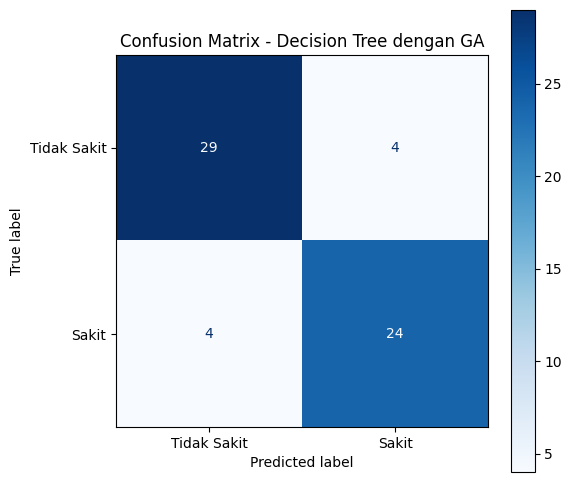

In [34]:
# Operator seleksi (misalnya, Tournamen Selection)
toolbox.register("select", tools.selTournament, tournsize=3)

# Operator crossover (misalnya, Two-point Crossover)
toolbox.register("mate", tools.cxTwoPoint)

# Operator mutasi
def mutate_individual(individual, indpb_max_depth, indpb_min_samples_split, indpb_min_samples_leaf, indpb_criterion):
    # Mutasi max_depth
    if random.random() < indpb_max_depth:
        individual[0] = random.randint(MAX_DEPTH_MIN, MAX_DEPTH_MAX)
    # Mutasi min_samples_split
    if random.random() < indpb_min_samples_split:
        individual[1] = random.randint(MIN_SAMPLES_SPLIT_MIN, MIN_SAMPLES_SPLIT_MAX)
    # Mutasi min_samples_leaf
    if random.random() < indpb_min_samples_leaf:
        individual[2] = random.randint(MIN_SAMPLES_LEAF_MIN, MIN_SAMPLES_LEAF_MAX)
    # Mutasi criterion
    if random.random() < indpb_criterion:
        individual[3] = random.choice(CRITERION_OPTIONS)
    return individual,

toolbox.register("mutate", mutate_individual,
                 indpb_max_depth=0.2,
                 indpb_min_samples_split=0.2,
                 indpb_min_samples_leaf=0.2,
                 indpb_criterion=0.2)

# Atur Parameter Algoritma Genetika
POPULATION_SIZE = 50
GENERATIONS = 20
CXPB = 0.7  # Probabilitas Crossover
MUTPB = 0.3 # Probabilitas Mutasi

# Jalankan Algoritma Genetika
print(f"Memulai Algoritma Genetika untuk {GENERATIONS} generasi dengan populasi {POPULATION_SIZE}...")

# Buat populasi awal secara acak
population = toolbox.population(n=POPULATION_SIZE)

# Evaluasi semua individu dalam populasi
fitnesses = list(map(toolbox.evaluate, population))
for ind, fit in zip(population, fitnesses):
    ind.fitness.values = fit

# Inisialisasi HallOfFame sebelum memanggil eaSimple
halloffame = tools.HallOfFame(1)

# Log statistik evolusi
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=GENERATIONS,
                    stats=stats, halloffame=halloffame, verbose=True)

# Ambil individu terbaik dari HallOfFame
best_individual = halloffame[0]

print("\n=== HASIL OPTIMASI DECISION TREE DENGAN ALGORITMA GENETIKA ===")
print(f"Individu Terbaik (Hyperparameter): {best_individual}")
print(f"Max Depth: {best_individual[0]}")
print(f"Min Samples Split: {best_individual[1]}")
print(f"Min Samples Leaf: {best_individual[2]}")
print(f"Criterion: {best_individual[3]}")
print(f"F1-Score Terbaik pada Data Uji: {best_individual.fitness.values[0]:.4f}")

# Latih ulang model dengan hyperparameter terbaik untuk visualisasi atau penggunaan lebih lanjut
best_dt_model = DecisionTreeClassifier(
    max_depth=best_individual[0],
    min_samples_split=best_individual[1],
    min_samples_leaf=best_individual[2],
    criterion=best_individual[3],
    random_state=42
)
best_dt_model.fit(X_train, y_train)
y_pred_ga = best_dt_model.predict(X_test)

print("\n=== CLASSIFICATION REPORT DENGAN HYPERPARAMETER TERBAIK (GA) ===")
print(classification_report(y_test, y_pred_ga, target_names=['Tidak Sakit (0)', 'Sakit (1)']))

cm_ga = confusion_matrix(y_test, y_pred_ga)
disp_ga = ConfusionMatrixDisplay(confusion_matrix=cm_ga, display_labels=['Tidak Sakit', 'Sakit'])
fig_ga, ax_ga = plt.subplots(figsize=(6, 6))
disp_ga.plot(cmap=plt.cm.Blues, ax=ax_ga)
plt.title("Confusion Matrix - Decision Tree dengan GA")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, average_precision_score, balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score

y_prob_ga = best_dt_model.predict_proba(X_test)[:, 1] # Probabilitas kelas positif

ga_metrics = {
    "model": "Decision Tree (Genetic Algorithm)",
    "accuracy": accuracy_score(y_test, y_pred_ga),
    "precision": precision_score(y_test, y_pred_ga, zero_division=0),
    "recall": recall_score(y_test, y_pred_ga, zero_division=0),
    "f1": f1_score(y_test, y_pred_ga, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, y_pred_ga),
    "mcc": matthews_corrcoef(y_test, y_pred_ga),
    "kappa": cohen_kappa_score(y_test, y_pred_ga),
    "auc": roc_auc_score(y_test, y_prob_ga),
    "average_precision": average_precision_score(y_test, y_prob_ga),
    "logloss": log_loss(y_test, y_prob_ga, labels=[0, 1]),
    "n_data": len(y_test),
}

ga_metrics_df = pd.DataFrame([ga_metrics])

print("\n=== RINGKASAN METRIK MODEL DECISION TREE (ALGORITMA GENETIKA) PADA DATA UJI ===")
display(ga_metrics_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "balanced_acc": "{:.3f}",
    "mcc": "{:.3f}",
    "kappa": "{:.3f}",
    "auc": "{:.3f}",
    "average_precision": "{:.3f}",
    "logloss": "{:.3f}",
}))


=== RINGKASAN METRIK MODEL DECISION TREE (ALGORITMA GENETIKA) PADA DATA UJI ===


,model,accuracy,precision,recall,f1,balanced_acc,mcc,kappa,auc,average_precision,logloss,n_data
0,Decision Tree (Genetic Algorithm),0.869,0.857,0.857,0.857,0.868,0.736,0.736,0.880,0.802,1.495,61


## Evolutionary XGBoost

In [36]:
from deap import base, creator, tools, algorithms
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, log_loss, accuracy_score, precision_score, recall_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd


In [37]:
N_ESTIMATORS_MIN, N_ESTIMATORS_MAX = 50, 500
MAX_DEPTH_MIN_XGB, MAX_DEPTH_MAX_XGB = 1, 10
LEARNING_RATE_MIN, LEARNING_RATE_MAX = 0.01, 0.3
SUBSAMPLE_MIN, SUBSAMPLE_MAX = 0.5, 1.0
COLSAMPLE_BYTREE_MIN, COLSAMPLE_BYTREE_MAX = 0.5, 1.0
GAMMA_MIN, GAMMA_MAX = 0.0, 0.5
MIN_CHILD_WEIGHT_MIN, MIN_CHILD_WEIGHT_MAX = 1, 10

# Reuse creator.create from previous cell if already defined (it throws error if run twice)
try:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
except AttributeError:
    pass

toolbox_xgb = base.Toolbox()

# Fungsi untuk menghasilkan setiap hyperparameter secara acak
toolbox_xgb.register("attr_n_estimators", random.randint, N_ESTIMATORS_MIN, N_ESTIMATORS_MAX)
toolbox_xgb.register("attr_max_depth_xgb", random.randint, MAX_DEPTH_MIN_XGB, MAX_DEPTH_MAX_XGB)
toolbox_xgb.register("attr_learning_rate", random.uniform, LEARNING_RATE_MIN, LEARNING_RATE_MAX)
toolbox_xgb.register("attr_subsample", random.uniform, SUBSAMPLE_MIN, SUBSAMPLE_MAX)
toolbox_xgb.register("attr_colsample_bytree", random.uniform, COLSAMPLE_BYTREE_MIN, COLSAMPLE_BYTREE_MAX)
toolbox_xgb.register("attr_gamma", random.uniform, GAMMA_MIN, GAMMA_MAX)
toolbox_xgb.register("attr_min_child_weight", random.randint, MIN_CHILD_WEIGHT_MIN, MIN_CHILD_WEIGHT_MAX)

# Fungsi untuk merakit individu dari hyperparameter yang dihasilkan
toolbox_xgb.register("individual", tools.initCycle, creator.Individual,
                 (toolbox_xgb.attr_n_estimators,
                  toolbox_xgb.attr_max_depth_xgb,
                  toolbox_xgb.attr_learning_rate,
                  toolbox_xgb.attr_subsample,
                  toolbox_xgb.attr_colsample_bytree,
                  toolbox_xgb.attr_gamma,
                  toolbox_xgb.attr_min_child_weight), n=1)

# Fungsi untuk membuat populasi
toolbox_xgb.register("population", tools.initRepeat, list, toolbox_xgb.individual)

# Definisikan Fungsi Fitness (Evaluasi) untuk XGBoost
def evaluate_xgb(individual):
    n_estimators = individual[0]
    max_depth = individual[1]
    learning_rate = individual[2]
    subsample = individual[3]
    colsample_bytree = individual[4]
    gamma = individual[5]
    min_child_weight = individual[6]

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight,
        use_label_encoder=False, # Suppress warning
        eval_metric='logloss', # Specify evaluation metric
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    return f1,

toolbox_xgb.register("evaluate", evaluate_xgb)

c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.


Memulai Algoritma Genetika untuk XGBoost untuk 20 generasi dengan populasi 50...
gen	nevals	avg     	std      	min     	max     
0  	0     	0,874327	0,0179292	0,833333	0,915254
1  	42    	0,879535	0,018518 	0,847458	0,915254
2  	39    	0,880553	0,0202612	0,819672	0,915254
3  	44    	0,889934	0,0168221	0,847458	0,915254
4  	41    	0,895657	0,0212375	0,83871 	0,931034
5  	40    	0,894472	0,0276298	0,769231	0,931034
6  	46    	0,896281	0,0223779	0,842105	0,918033
7  	35    	0,903764	0,0203147	0,857143	0,931034
8  	43    	0,906627	0,0158757	0,862069	0,918033
9  	35    	0,90636 	0,0188535	0,833333	0,918033
10 	47    	0,910583	0,0174355	0,83871 	0,918033
11 	35    	0,90949 	0,0186555	0,847458	0,918033
12 	40    	0,915014	0,00954709	0,866667	0,918033
13 	37    	0,913276	0,0152432 	0,847458	0,918033
14 	44    	0,908936	0,0207065 	0,852459	0,918033
15 	39    	0,906332	0,0218154 	0,83871 	0,918033
16 	42    	0,913911	0,0130992 	0,852459	0,918033
17 	35    	0,913371	0,0149834 	0,847458	0,918033
1

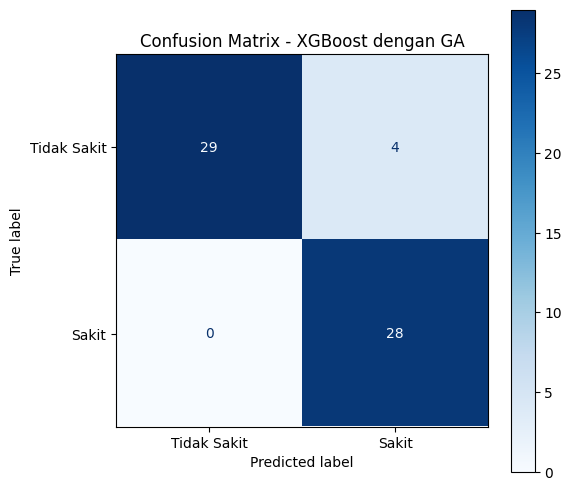


=== RINGKASAN METRIK MODEL XGBOOST (ALGORITMA GENETIKA) PADA DATA UJI ===


,model,accuracy,precision,recall,f1,balanced_acc,mcc,kappa,auc,average_precision,logloss,n_data
0,XGBoost (Genetic Algorithm),0.934,0.875,1.000,0.933,0.939,0.877,0.869,0.964,0.938,0.280,61


In [38]:
toolbox_xgb.register("select", tools.selTournament, tournsize=3)

toolbox_xgb.register("mate", tools.cxTwoPoint)

# Operator mutasi
def mutate_xgb_individual(individual,
                          indpb_n_estimators,
                          indpb_max_depth,
                          indpb_learning_rate,
                          indpb_subsample,
                          indpb_colsample_bytree,
                          indpb_gamma,
                          indpb_min_child_weight):

    # Mutasi n_estimators
    if random.random() < indpb_n_estimators:
        individual[0] = random.randint(N_ESTIMATORS_MIN, N_ESTIMATORS_MAX)
    # Mutasi max_depth
    if random.random() < indpb_max_depth:
        individual[1] = random.randint(MAX_DEPTH_MIN_XGB, MAX_DEPTH_MAX_XGB)
    # Mutasi learning_rate
    if random.random() < indpb_learning_rate:
        individual[2] = random.uniform(LEARNING_RATE_MIN, LEARNING_RATE_MAX)
    # Mutasi subsample
    if random.random() < indpb_subsample:
        individual[3] = random.uniform(SUBSAMPLE_MIN, SUBSAMPLE_MAX)
    # Mutasi colsample_bytree
    if random.random() < indpb_colsample_bytree:
        individual[4] = random.uniform(COLSAMPLE_BYTREE_MIN, COLSAMPLE_BYTREE_MAX)
    # Mutasi gamma
    if random.random() < indpb_gamma:
        individual[5] = random.uniform(GAMMA_MIN, GAMMA_MAX)
    # Mutasi min_child_weight
    if random.random() < indpb_min_child_weight:
        individual[6] = random.randint(MIN_CHILD_WEIGHT_MIN, MIN_CHILD_WEIGHT_MAX)

    return individual,

toolbox_xgb.register("mutate", mutate_xgb_individual,
                     indpb_n_estimators=0.2,
                     indpb_max_depth=0.2,
                     indpb_learning_rate=0.2,
                     indpb_subsample=0.2,
                     indpb_colsample_bytree=0.2,
                     indpb_gamma=0.2,
                     indpb_min_child_weight=0.2)

# Atur Parameter Algoritma Genetika
POPULATION_SIZE_XGB = 50
GENERATIONS_XGB = 20
CXPB_XGB = 0.7  # Probabilitas Crossover
MUTPB_XGB = 0.3 # Probabilitas Mutasi

# Jalankan Algoritma Genetika
print(f"Memulai Algoritma Genetika untuk XGBoost untuk {GENERATIONS_XGB} generasi dengan populasi {POPULATION_SIZE_XGB}...")

population_xgb = toolbox_xgb.population(n=POPULATION_SIZE_XGB)

fitnesses_xgb = list(map(toolbox_xgb.evaluate, population_xgb))
for ind, fit in zip(population_xgb, fitnesses_xgb):
    ind.fitness.values = fit

halloffame_xgb = tools.HallOfFame(1)

stats_xgb = tools.Statistics(lambda ind: ind.fitness.values)
stats_xgb.register("avg", np.mean)
stats_xgb.register("std", np.std)
stats_xgb.register("min", np.min)
stats_xgb.register("max", np.max)

algorithms.eaSimple(population_xgb, toolbox_xgb, cxpb=CXPB_XGB, mutpb=MUTPB_XGB, ngen=GENERATIONS_XGB,
                    stats=stats_xgb, halloffame=halloffame_xgb, verbose=True)

best_individual_xgb = halloffame_xgb[0]

print("\n=== HASIL OPTIMASI XGBOOST DENGAN ALGORITMA GENETIKA ===")
print(f"Individu Terbaik (Hyperparameter): {best_individual_xgb}")
print(f"n_estimators: {best_individual_xgb[0]}")
print(f"max_depth: {best_individual_xgb[1]}")
print(f"learning_rate: {best_individual_xgb[2]:.4f}")
print(f"subsample: {best_individual_xgb[3]:.4f}")
print(f"colsample_bytree: {best_individual_xgb[4]:.4f}")
print(f"gamma: {best_individual_xgb[5]:.4f}")
print(f"min_child_weight: {best_individual_xgb[6]}")
print(f"F1-Score Terbaik pada Data Uji: {best_individual_xgb.fitness.values[0]:.4f}")

# Latih ulang model dengan hyperparameter terbaik untuk visualisasi atau penggunaan lebih lanjut
best_xgb_model = XGBClassifier(
    n_estimators=best_individual_xgb[0],
    max_depth=best_individual_xgb[1],
    learning_rate=best_individual_xgb[2],
    subsample=best_individual_xgb[3],
    colsample_bytree=best_individual_xgb[4],
    gamma=best_individual_xgb[5],
    min_child_weight=best_individual_xgb[6],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
best_xgb_model.fit(X_train, y_train)
y_pred_xgb_ga = best_xgb_model.predict(X_test)
y_prob_xgb_ga = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT DENGAN HYPERPARAMETER TERBAIK (XGBOOST GA) ===")
print(classification_report(y_test, y_pred_xgb_ga, target_names=['Tidak Sakit (0)', 'Sakit (1)']))

cm_xgb_ga = confusion_matrix(y_test, y_pred_xgb_ga)
disp_xgb_ga = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_ga, display_labels=['Tidak Sakit', 'Sakit'])
fig_xgb_ga, ax_xgb_ga = plt.subplots(figsize=(6, 6))
disp_xgb_ga.plot(cmap=plt.cm.Blues, ax=ax_xgb_ga)
plt.title("Confusion Matrix - XGBoost dengan GA")
plt.show()

xgb_ga_metrics = {
    "model": "XGBoost (Genetic Algorithm)",
    "accuracy": accuracy_score(y_test, y_pred_xgb_ga),
    "precision": precision_score(y_test, y_pred_xgb_ga, zero_division=0),
    "recall": recall_score(y_test, y_pred_xgb_ga, zero_division=0),
    "f1": f1_score(y_test, y_pred_xgb_ga, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, y_pred_xgb_ga),
    "mcc": matthews_corrcoef(y_test, y_pred_xgb_ga),
    "kappa": cohen_kappa_score(y_test, y_pred_xgb_ga),
    "auc": roc_auc_score(y_test, y_prob_xgb_ga),
    "average_precision": average_precision_score(y_test, y_prob_xgb_ga),
    "logloss": log_loss(y_test, y_prob_xgb_ga, labels=[0, 1]),
    "n_data": len(y_test),
}

xgb_ga_metrics_df = pd.DataFrame([xgb_ga_metrics])

print("\n=== RINGKASAN METRIK MODEL XGBOOST (ALGORITMA GENETIKA) PADA DATA UJI ===")
display(xgb_ga_metrics_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "balanced_acc": "{:.3f}",
    "mcc": "{:.3f}",
    "kappa": "{:.3f}",
    "auc": "{:.3f}",
    "average_precision": "{:.3f}",
    "logloss": "{:.3f}",
}))